<a href="https://colab.research.google.com/github/Penny-1218-colab/food/blob/main/411400225%E6%9D%8E%E6%B2%9B%E5%AE%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

解壓完成
Found 300 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step - accuracy: 0.4033 - loss: 1.7232
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.6833 - loss: 0.8147
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.7967 - loss: 0.5418
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.9167 - loss: 0.3420
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9500 - loss: 0.2206


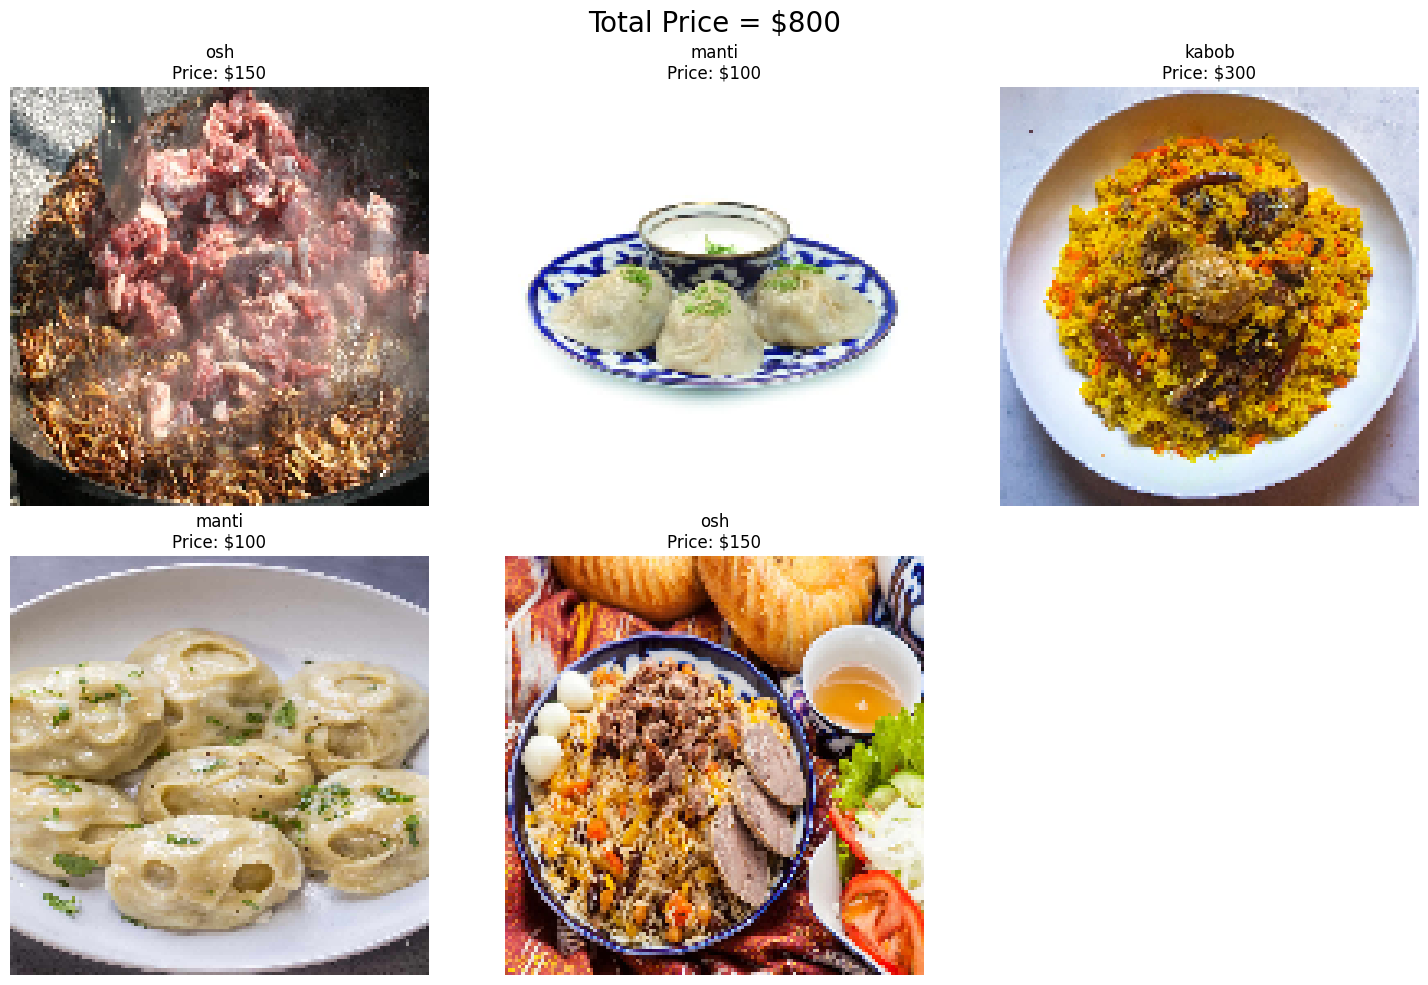

總價格：$800


In [2]:
# ==============================
# 食物辨識 + 自動計價系統
# ==============================
!pip install tensorflow -q
import zipfile
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
# ==============================
# 1. 解壓縮
# ==============================
zip_path = "/content/food.zip"
extract_path = "/content/food"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("解壓完成")
# ==============================
# 2. 資料路徑
# ==============================
train_dir = "/content/food/train"
test_dir = "/content/food/test"
# ==============================
# 3. Data Generator
# ==============================
train_gen = ImageDataGenerator(
    rescale=1./255
)
test_gen = ImageDataGenerator(
    rescale=1./255
)
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)
test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
# ==============================
# 4. CNN 模型
# ==============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])
# ==============================
# 5. 編譯模型
# ==============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# ==============================
# 6. 訓練模型
# ==============================
model.fit(
    train_data,
    epochs=5
)
# ==============================
# 7. 類別與價格
# ==============================
class_names = list(train_data.class_indices.keys())
price_dict = {
    "manti": 100,
    "osh": 150,
    "kabob": 300
}
# ==============================
# 8. 測試圖片
# ==============================
test_images = []
for folder in class_names:
    folder_path = os.path.join(test_dir, folder)
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg','.png','.jpeg')):
            test_images.append(
                os.path.join(folder_path, file)
            )
# 隨機抽 5 張
sample_images = random.sample(test_images, 5)
# ==============================
# 9. 預測 + 計價
# ==============================
total_price = 0
plt.figure(figsize=(15,10))
for i, img_path in enumerate(sample_images):
    img = image.load_img(img_path,
                         target_size=(128,128))

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)
    pred_index = np.argmax(prediction)
    pred_class = class_names[pred_index]
    price = price_dict[pred_class]
    total_price += price
    # 顯示圖片
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(
        f"{pred_class}\nPrice: ${price}"
    )
    plt.axis("off")
# ==============================
# 10. 顯示總價
# ==============================
plt.suptitle(
    f"Total Price = ${total_price}",
    fontsize=20
)
plt.tight_layout()
plt.show()
print(f"總價格：${total_price}")